In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import differential_evolution
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
import openpyxl
import pandas as pd
import time

import torch
import torch.nn as nn
import torch.utils.data

In [2]:
def blackscholes_price(K, T, S, vol, r=0, q=0, callput='call'):
    F = S * np.exp((r - q) * T)
    w = vol**2 * T
    d1 = (np.log(F / K) + 0.5 * w) / np.sqrt(w)
    d2 = d1 - np.sqrt(w)
    opttype = 1 if callput.lower() == 'call' else -1
    price = opttype * (F * norm.cdf(opttype * d1) - K * norm.cdf(opttype * d2)) * np.exp(-r * T)
    return price

def blackscholes_impv_scalar(K, T, S, value, r=0, q=0, callput='call', tol=1e-6, maxiter=500):
    if (K <= 0) or (T <= 0):
        return np.nan
    F = S * np.exp((r - q) * T)
    K_norm = K / F
    value = value * np.exp(r * T) / F
    opttype = 1 if callput.lower() == 'call' else -1
    value -= max(opttype * (1 - K_norm), 0)
    if value < 0:
        return np.nan
    if value == 0:
        return 0
    j = 1
    p = np.log(K_norm)
    if K_norm >= 1:
        x0 = np.sqrt(2 * p)
        x1 = x0 - (0.5 - K_norm * norm.cdf(-x0) - value) * np.sqrt(2 * np.pi)
        while (abs(x0 - x1) > tol * np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p / x1 + 0.5 * x1
            x1 = x1 - (norm.cdf(d1) - K_norm * norm.cdf(d1 - x1) - value) * np.sqrt(2 * np.pi) * np.exp(0.5 * d1**2)
            j += 1
    else:
        x0 = np.sqrt(-2 * p)
        x1 = x0 - (0.5 * K_norm - norm.cdf(-x0) - value) * np.sqrt(2 * np.pi) / K_norm
        while (abs(x0 - x1) > tol * np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p / x1 + 0.5 * x1
            x1 = x1 - (K_norm * norm.cdf(x1 - d1) - norm.cdf(-d1) - value) * np.sqrt(2 * np.pi) * np.exp(0.5 * d1**2)
            j += 1
    return x1 / np.sqrt(T)

blackscholes_impv = np.vectorize(blackscholes_impv_scalar, excluded={'callput', 'tol', 'maxiter'})

def quartic_kernel(x):
    x = np.clip(x, -1, 1)
    return (x + 1)**2 * (1 - x)**2

In [3]:
# ── Price history ─────────────────────────────────────────────────────────────
df_price = pd.read_excel('sample_data_Mar17.xlsx', sheet_name='NVDA Price')
df_price.columns = ['date', 'close', 'volume', 'smavg15']
df_price['date']  = pd.to_datetime(df_price['date'], dayfirst=True)
df_price = (df_price.dropna(subset=['close'])
                    .sort_values('date')
                    .reset_index(drop=True))
df_price['close'] = df_price['close'].astype(float)
S0_nvda = float(df_price['close'].iloc[-1])

# ── Options data ──────────────────────────────────────────────────────────────
wb = openpyxl.load_workbook('sample_data_Mar17.xlsx')
ws = wb['NVDA Options']

expiries = []
current  = None

for row in ws.iter_rows(values_only=True):
    if row[0] in ('Strike', 'Calls') or row[0] is None:
        continue
    if isinstance(row[0], str) and 'CSize' in row[0]:
        header  = row[0]
        days    = int(header.split('(')[1].split('d')[0])
        T_exp   = days / 365.0
        R       = float(header.split('R ')[1].split(';')[0]) / 100.0
        IFwd    = float(header.split('IFwd ')[1].replace(')', '').strip())
        current = {'T': T_exp, 'R': R, 'IFwd': IFwd,
                   'strikes': [], 'ivs': [], 'vols': []}
        expiries.append(current)
    elif current is not None and isinstance(row[0], (int, float)):
        K_    = float(row[0])
        iv_c  = float(row[5]) / 100.0
        iv_p  = float(row[12]) / 100.0
        vol_c = float(row[6]) if row[6] else 0.0
        vol_p = float(row[13]) if row[13] else 0.0
        denom = vol_c + vol_p
        iv_mid = (iv_c * vol_c + iv_p * vol_p) / denom if denom > 0 else (iv_c + iv_p) / 2.0
        current['strikes'].append(K_)
        current['ivs'].append(iv_mid)
        current['vols'].append(denom)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"S0_nvda = {S0_nvda}")
print(f"Expiries loaded: {len(expiries)}")
for exp in expiries:
    print(f"  T={exp['T']:.4f} ({int(exp['T']*365)}d)  "
          f"R={exp['R']:.4f}  IFwd={exp['IFwd']:.2f}  "
          f"n_strikes={len(exp['strikes'])}  "
          f"K=[{min(exp['strikes']):.0f}, {max(exp['strikes']):.0f}]")
print(f"\nPrice history: {len(df_price)} rows  "
      f"{df_price['date'].min().date()} → {df_price['date'].max().date()}")

S0_nvda = 183.22
Expiries loaded: 4
  T=0.0110 (4d)  R=0.0396  IFwd=183.56  n_strikes=20  K=[160, 208]
  T=0.0877 (32d)  R=0.0396  IFwd=184.09  n_strikes=20  K=[140, 235]
  T=0.1644 (60d)  R=0.0396  IFwd=184.62  n_strikes=20  K=[140, 235]
  T=0.2575 (94d)  R=0.0396  IFwd=185.26  n_strikes=20  K=[174, 193]

Price history: 1269 rows  2021-02-25 → 2026-03-16


In [4]:
def heston_char_func(u, j, T, S0, r, q, v0, kappa, theta, xi, rho):
    """
    Heston characteristic function φ_j(u) for j ∈ {1, 2}.
    'Little Heston Trap' formulation (Albrecher et al. 2007) —
    ensures |g| < 1 so that g·e^{-dT} decays and the log stays real.
    Vectorised over u (1-D complex array).
    """
    u = np.asarray(u, dtype=np.complex128)

    bj = (kappa - rho * xi) if j == 1 else kappa
    uj = 0.5 if j == 1 else -0.5

    alpha = bj - rho * xi * 1j * u
    d     = np.sqrt(alpha**2 + xi**2 * (u**2 - 2.0 * uj * 1j * u))

    g       = (alpha - d) / (alpha + d)
    exp_mdt = np.exp(-d * T)

    D_val = ((alpha - d) / xi**2) * (1.0 - exp_mdt) / (1.0 - g * exp_mdt)
    C_val = (1j * u * (np.log(S0) + (r - q) * T)
             + (kappa * theta / xi**2)
               * ((alpha - d) * T
                  - 2.0 * np.log((1.0 - g * exp_mdt) / (1.0 - g))))

    return np.exp(C_val + D_val * v0)


def heston_call_grid(S0, K_arr, T, r, q, v0, kappa, theta, xi, rho,
                     n_quad=256):
    """
    European call prices for a *vector* of strikes at a single expiry.
    Uses Gauss–Legendre quadrature on [ε, u_max].
    """
    K_arr = np.atleast_1d(np.asarray(K_arr, dtype=float))
    if T < 1e-10:
        return np.maximum(S0 * np.exp(-q * T) - K_arr, 0.0)

    eps   = 1e-8
    u_max = 300.0
    nodes, weights = np.polynomial.legendre.leggauss(n_quad)
    u = (nodes + 1.0) / 2.0 * (u_max - eps) + eps   
    w = weights * (u_max - eps) / 2.0        

    cf1 = heston_char_func(u, 1, T, S0, r, q, v0, kappa, theta, xi, rho)
    cf2 = heston_char_func(u, 2, T, S0, r, q, v0, kappa, theta, xi, rho)

    logK   = np.log(K_arr)                  
    phase  = np.exp(-1j * u[None, :] * logK[:, None])
    inv_iu = 1.0 / (1j * u[None, :])                

    P1 = 0.5 + np.dot(np.real(phase * cf1[None, :] * inv_iu), w) / np.pi
    P2 = 0.5 + np.dot(np.real(phase * cf2[None, :] * inv_iu), w) / np.pi

    return np.maximum(S0 * np.exp(-q * T) * P1
                      - K_arr * np.exp(-r * T) * P2, 0.0)

_test_v0 = 0.04
_pc = heston_call_grid(100, np.array([100.0]), 1.0, 0.05, 0.0,
                        _test_v0, 2.0, _test_v0, 1e-6, -0.5)[0]
_pb = blackscholes_price(100, 1.0, 100, np.sqrt(_test_v0), r=0.05, callput='call')
print(f"Heston (ξ→0) = {_pc:.6f}  |  BS = {_pb:.6f}  |  match = {np.isclose(_pc, _pb, atol=0.01)}")

_c = heston_call_grid(100, np.array([90.0, 100.0, 110.0]), 1.0, 0.05, 0.0,
                       0.04, 2.0, 0.04, 0.5, -0.7)
for _K, _p in zip([90, 100, 110], _c):
    _iv = blackscholes_impv_scalar(_K, 1.0, 100, float(_p), r=0.05, callput='call')
    print(f"  K={_K}  price={_p:.6f}  IV={_iv:.4f}")

Heston (ξ→0) = 10.450455  |  BS = 10.450584  |  match = True
  K=90  price=17.140055  IV=0.2159
  K=100  price=10.154627  IV=0.1921
  K=110  price=4.866183  IV=0.1702


In [5]:
def calibrate_heston(expiries, S0, n_quad=128):
    groups  = []
    n_total = 0
    for exp in expiries:
        T = exp['T'];  r = exp['R'];  F = exp['IFwd']
        q = r - np.log(F / S0) / T if T > 1e-8 else 0.0
        K_arr  = np.array(exp['strikes'], dtype=float)
        iv_arr = np.array(exp['ivs'],     dtype=float)
        mkt_prices = np.array([
            blackscholes_price(K, T, S0, iv, r=r, q=q, callput='call')
            for K, iv in zip(K_arr, iv_arr)])
        vegas = np.array([
            S0 * np.sqrt(T) * np.exp(-0.5 * ((np.log(S0/K) + (r - q + 0.5*iv**2)*T) / (iv*np.sqrt(T)))**2) / np.sqrt(2*np.pi )
            for K, iv in zip(K_arr, iv_arr)])
        vegas = np.maximum(vegas, 1e-6)
        n_total += len(K_arr)
        groups.append(dict(T=T, r=r, q=q, K=K_arr, iv=iv_arr, mkt_prices=mkt_prices, vegas=vegas))

    def objective(params):
        v0, kappa, theta, xi, rho = params
        err = 0.0
        for g in groups:
            try:
                prices = heston_call_grid(S0, g['K'], g['T'], g['r'], g['q'],v0, kappa, theta, xi, rho, n_quad=n_quad)
                err += np.sum(((prices - g['mkt_prices']) / g['vegas'])**2)
            except Exception:
                return 1e6
        return err / n_total

    bounds = [
        (0.01,  1.0),
        (0.01, 20.0),
        (0.01,  1.0),
        (0.01,  4.0),
        (-0.99, 0.99),
    ]

    print("Calibrating Heston ...")
    result = differential_evolution(
        objective, bounds, seed=42,
        maxiter=150, tol=1e-9, polish=True,
        mutation=(0.5, 1.5), recombination=0.9, popsize=10)

    v0, kappa, theta, xi, rho = result.x
    rmse = np.sqrt(result.fun)

    print(f"\n{'='*60}")
    print(f"  v0    = {v0:.6f}   (sigma0 = {np.sqrt(v0):.4f})")
    print(f"  kappa = {kappa:.4f}")
    print(f"  theta = {theta:.6f}   (sigma_inf = {np.sqrt(theta):.4f})")
    print(f"  xi    = {xi:.4f}")
    print(f"  rho   = {rho:.4f}")
    print(f"  RMSE  = {rmse:.6f}")
    print(f"  Feller: 2*kappa*theta = {2*kappa*theta:.4f}  vs  xi^2 = {xi**2:.4f}  "
          f"({'OK' if 2*kappa*theta > xi**2 else 'VIOLATED'})")

    print()
    for g in groups:
        prices = heston_call_grid(S0, g['K'], g['T'], g['r'], g['q'],
                                  v0, kappa, theta, xi, rho, n_quad=256)
        print(f"  T={g['T']:.4f} ({int(g['T']*365)}d)")
        for K, price, iv_mkt in zip(g['K'], prices, g['iv']):
            iv_mod = blackscholes_impv_scalar(
                K, g['T'], S0, float(price), r=g['r'], q=g['q'], callput='call')
            tag = 'OK' if abs(iv_mod - iv_mkt) < 0.005 else 'X'
            print(f"    K={K:>7.1f}  mkt={iv_mkt:.4f}  "
                  f"mod={iv_mod:.4f}  err={abs(iv_mod-iv_mkt):.5f}  {tag}")

    return result.x

heston_params = calibrate_heston(expiries, S0_nvda)

Calibrating Heston ...

  v0    = 0.169275   (sigma0 = 0.4114)
  kappa = 20.0000
  theta = 0.206752   (sigma_inf = 0.4547)
  xi    = 4.0000
  rho   = -0.4940
  RMSE  = 0.015206
  Feller: 2*kappa*theta = 8.2701  vs  xi^2 = 16.0000  (VIOLATED)

  T=0.0110 (4d)
    K=  160.0  mkt=0.6168  mod=0.5555  err=0.06128  X
    K=  162.5  mkt=0.5772  mod=0.5402  err=0.03701  X
    K=  165.0  mkt=0.5490  mod=0.5246  err=0.02436  X
    K=  167.5  mkt=0.5266  mod=0.5087  err=0.01782  X
    K=  170.0  mkt=0.5038  mod=0.4925  err=0.01136  X
    K=  172.5  mkt=0.4782  mod=0.4759  err=0.00234  OK
    K=  175.0  mkt=0.4571  mod=0.4589  err=0.00186  OK
    K=  177.5  mkt=0.4368  mod=0.4417  err=0.00489  OK
    K=  180.0  mkt=0.4202  mod=0.4245  err=0.00425  OK
    K=  182.5  mkt=0.4020  mod=0.4076  err=0.00555  X
    K=  185.0  mkt=0.3869  mod=0.3918  err=0.00495  OK
    K=  187.5  mkt=0.3748  mod=0.3786  err=0.00373  OK
    K=  190.0  mkt=0.3683  mod=0.3690  err=0.00068  OK
    K=  192.5  mkt=0.3648  mod=0

In [6]:
def build_heston_local_vol(S0, heston_params, expiries,
                            n_K=300, n_T=200, n_quad=256):
    v0, kappa_h, theta_h, xi_h, rho_h = heston_params

    T_mkt = np.array([e['T'] for e in expiries])
    r_mkt = np.array([e['R'] for e in expiries])
    F_mkt = np.array([e['IFwd'] for e in expiries])
    q_mkt = r_mkt - np.log(F_mkt / S0) / np.maximum(T_mkt, 1e-8)

    T_min  = 0.005
    T_max  = max(T_mkt) * 1.3
    T_grid = np.linspace(T_min, T_max, n_T)
    K_min  = S0 * 0.60
    K_max  = S0 * 1.60
    K_grid = np.linspace(K_min, K_max, n_K)

    r_grid = np.interp(T_grid, T_mkt, r_mkt)
    q_grid = np.interp(T_grid, T_mkt, q_mkt)

    print(f"Computing Heston call prices on a {n_T}x{n_K} grid ...")
    C = np.zeros((n_T, n_K))
    for i in range(n_T):
        C[i] = heston_call_grid(S0, K_grid, T_grid[i],
                                r_grid[i], q_grid[i],
                                v0, kappa_h, theta_h, xi_h, rho_h,
                                n_quad=n_quad)
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{n_T}")
    print(f"  Done.  C in [{C.min():.4f}, {C.max():.4f}]")

    dC_dT   = np.gradient(C,     T_grid, axis=0)
    dC_dK   = np.gradient(C,     K_grid, axis=1)
    d2C_dK2 = np.gradient(dC_dK, K_grid, axis=1)

    KK = K_grid[None, :]
    rr = r_grid[:, None]
    qq = q_grid[:, None]

    numer = 2.0 * (dC_dT + (rr - qq) * KK * dC_dK + qq * C)
    denom = KK**2 * d2C_dK2

    denom_safe = np.where(np.abs(denom) > 1e-12, denom, 1e-12)
    local_var  = np.clip(numer / denom_safe, 1e-4, 4.0)
    local_vol  = np.sqrt(local_var)

    local_vol = gaussian_filter(local_vol, sigma=[1.0, 1.0])
    local_vol = np.clip(local_vol, 0.01, 3.0)

    pct_clipped = 100 * np.mean((numer / denom_safe < 1e-4)
                                | (numer / denom_safe > 4.0))
    print(f"  Local vol in [{local_vol.min():.4f}, {local_vol.max():.4f}]"
          f"   ({pct_clipped:.1f}% of grid clipped)")

    lv_interp = RegularGridInterpolator(
        (T_grid, K_grid), local_vol,
        method='linear', bounds_error=False,
        fill_value=float(np.sqrt(theta_h)))

    T_mkt_min = T_mkt.min()

    def vol_fn(S, t):
        S_arr  = np.atleast_1d(np.asarray(S, dtype=float))
        t_clip = float(np.clip(t, T_grid[0], T_grid[-1]))
        S_clip = np.clip(S_arr, K_grid[0], K_grid[-1])
        pts    = np.stack([np.full(len(S_clip), t_clip), S_clip], axis=1)
        lv = np.clip(np.asarray(lv_interp(pts), dtype=float), 0.01, 3.0)
        if t < T_mkt_min:
            lv = np.where(lv < 0.05, float(np.sqrt(theta_h)), lv)
        return lv

    return vol_fn, T_grid, K_grid, local_vol

vol_fn_heston, T_lv, K_lv, lv_surface = build_heston_local_vol(
    S0_nvda, heston_params, expiries,
    n_K=300, n_T=200, n_quad=256)

Computing Heston call prices on a 200x300 grid ...
  50/200
  100/200
  150/200
  200/200
  Done.  C in [0.0000, 75.9494]
  Local vol in [0.0100, 1.8582]   (6.3% of grid clipped)


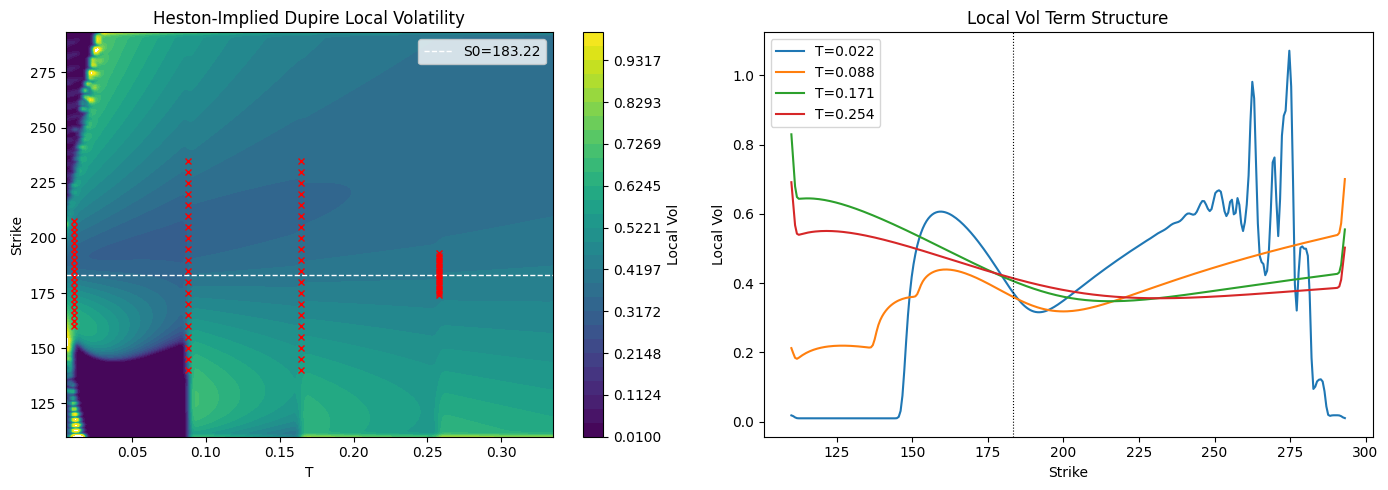

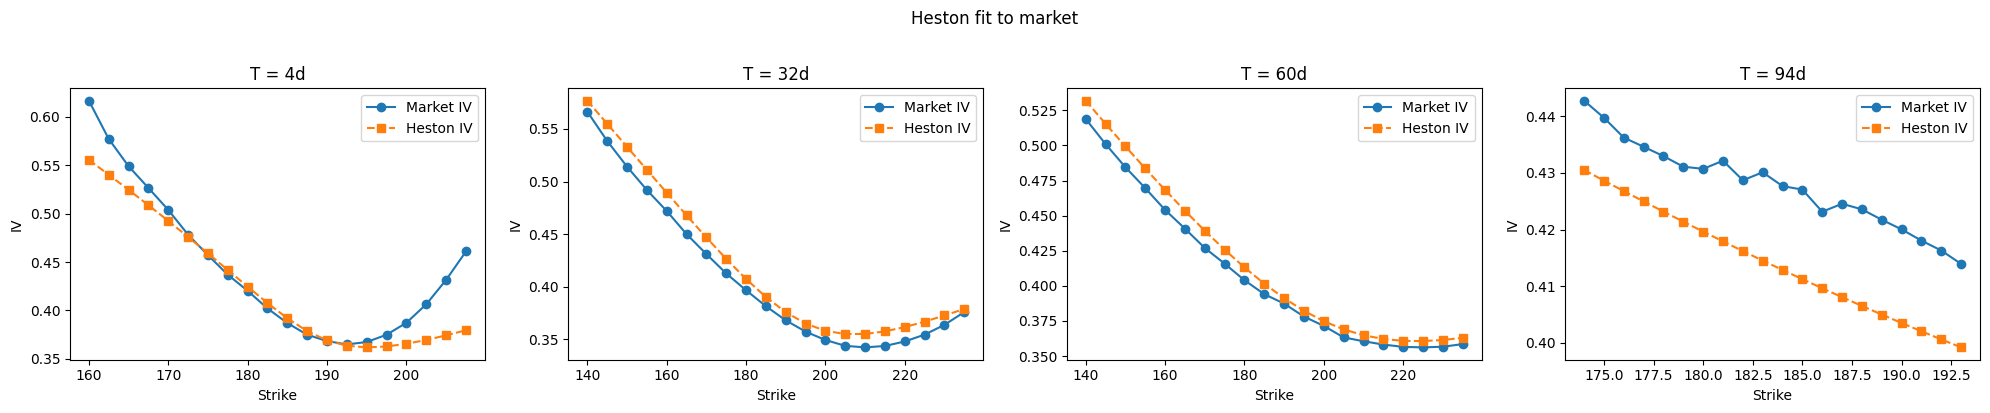

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

TT, KK = np.meshgrid(T_lv, K_lv, indexing='ij')
lvls = np.linspace(lv_surface.min(), min(lv_surface.max(), 1.0), 30)
cs = axes[0].contourf(TT, KK, lv_surface, levels=lvls, cmap='viridis')
plt.colorbar(cs, ax=axes[0], label='Local Vol')
axes[0].axhline(S0_nvda, color='w', ls='--', lw=1, label=f'S0={S0_nvda}')
for exp in expiries:
    for K in exp['strikes']:
        axes[0].plot(exp['T'], K, 'rx', ms=4)
axes[0].set_xlabel('T')
axes[0].set_ylabel('Strike')
axes[0].set_title('Heston-Implied Dupire Local Volatility')
axes[0].legend()

for t_slice in [T_lv[10], T_lv[50], T_lv[100], T_lv[150]]:
    idx = np.argmin(np.abs(T_lv - t_slice))
    axes[1].plot(K_lv, lv_surface[idx], label=f'T={T_lv[idx]:.3f}')
axes[1].axvline(S0_nvda, color='k', ls=':', lw=0.8)
axes[1].set_xlabel('Strike')
axes[1].set_ylabel('Local Vol')
axes[1].set_title('Local Vol Term Structure')
axes[1].legend()

plt.tight_layout()
plt.show()

v0_h, kappa_h, theta_h, xi_h, rho_h = heston_params
fig, axes = plt.subplots(1, len(expiries), figsize=(5*len(expiries), 4))
if len(expiries) == 1:
    axes = [axes]
for ax, exp in zip(axes, expiries):
    T = exp['T']; r = exp['R']; F = exp['IFwd']
    q = r - np.log(F / S0_nvda) / T if T > 1e-8 else 0.0
    K_arr = np.array(exp['strikes'])
    prices = heston_call_grid(S0_nvda, K_arr, T, r, q,
                              v0_h, kappa_h, theta_h, xi_h, rho_h)
    iv_mod = np.array([blackscholes_impv_scalar(K, T, S0_nvda, float(p),
                       r=r, q=q, callput='call')
                       for K, p in zip(K_arr, prices)])
    ax.plot(K_arr, exp['ivs'], 'o-', label='Market IV')
    ax.plot(K_arr, iv_mod, 's--', label='Heston IV')
    ax.set_xlabel('Strike'); ax.set_ylabel('IV')
    ax.set_title(f'T = {int(T*365)}d'); ax.legend()
plt.suptitle('Heston fit to market', y=1.02)
plt.tight_layout()
plt.show()

sigma0_slv (20d realized vol) = 0.3587
Long-run vol = 0.4853
Y0_slv       = -0.3025
rho_slv (spot-vol corr) = 0.1462


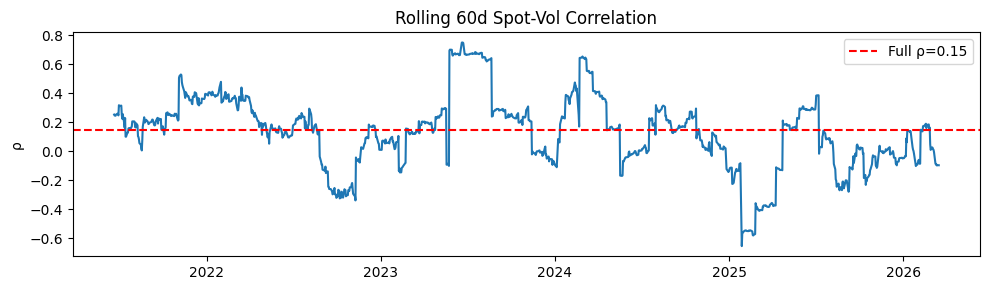

gamma_slv (vol of vol) = 1.1777
AR(1) slope     = 0.9776
Half-life       = 31 days
kappa_mr_slv    = 5.71


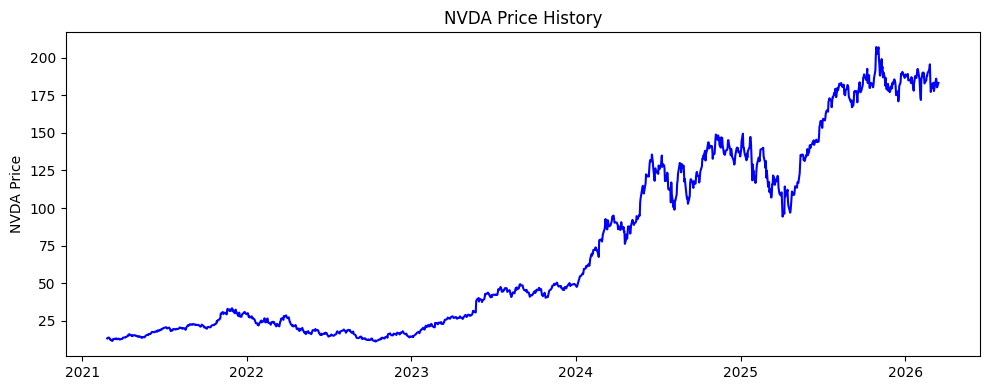

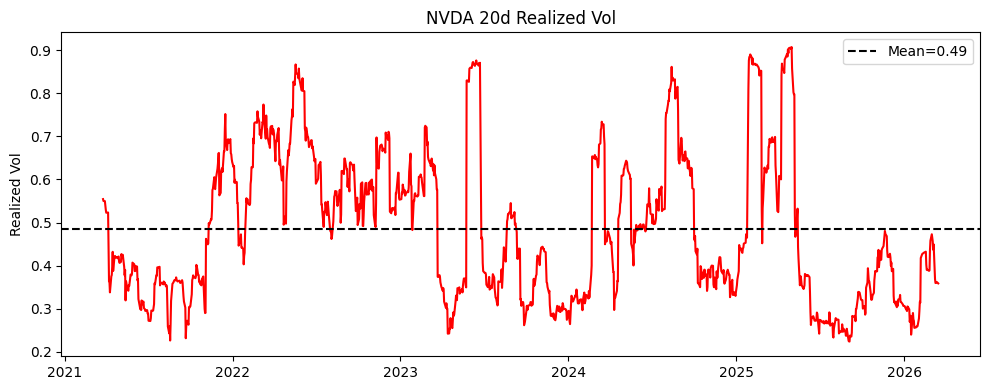


  ESTIMATED SLV PARAMETERS FROM NVDA HISTORY
  sigma0_slv   = 0.3587
  Y0_slv       = -0.3025
  rho_slv      = 0.1462
  gamma_slv    = 1.1777
  kappa_mr_slv = 5.71
  kappa_bw_slv = 1.0
  N_cal_slv    = 50000


In [8]:
df_price['log_ret'] = np.log(df_price['close'] / df_price['close'].shift(1))

window = 20
df_price['rvol'] = df_price['log_ret'].rolling(window).std() * np.sqrt(252)

sigma0_slv = df_price['rvol'].iloc[-1]
print(f"sigma0_slv (20d realized vol) = {sigma0_slv:.4f}")

long_run_vol = df_price['rvol'].dropna().mean()
Y0_slv = np.log(sigma0_slv / long_run_vol)
print(f"Long-run vol = {long_run_vol:.4f}")
print(f"Y0_slv       = {Y0_slv:.4f}")

df_price['d_rvol'] = df_price['rvol'].diff()
valid = df_price.dropna(subset=['log_ret', 'd_rvol'])

rho_slv = valid['log_ret'].corr(valid['d_rvol'])
print(f"rho_slv (spot-vol corr) = {rho_slv:.4f}")

rolling_rho = valid['log_ret'].rolling(60).corr(valid['d_rvol'])
plt.figure(figsize=(10, 3))
plt.plot(valid['date'], rolling_rho)
plt.axhline(rho_slv, color='r', ls='--', label=f'Full ρ={rho_slv:.2f}')
plt.ylabel('ρ')
plt.title('Rolling 60d Spot-Vol Correlation')
plt.legend()
plt.tight_layout()
plt.show()

df_price['log_rvol'] = np.log(df_price['rvol'])
valid2 = df_price.dropna(subset=['log_rvol'])
d_log_rvol = valid2['log_rvol'].diff().dropna()

gamma_slv = d_log_rvol.std() * np.sqrt(252)
print(f"gamma_slv (vol of vol) = {gamma_slv:.4f}")

y = valid2['log_rvol'].values[1:]
x = valid2['log_rvol'].values[:-1]
mask = np.isfinite(x) & np.isfinite(y)
x, y = x[mask], y[mask]

b = np.polyfit(x, y, 1)[0]
halflife_days = -np.log(2) / np.log(np.clip(b, 1e-6, 0.9999))
kappa_mr_slv = -252 * np.log(np.clip(b, 1e-6, 0.9999))

print(f"AR(1) slope     = {b:.4f}")
print(f"Half-life       = {halflife_days:.0f} days")
print(f"kappa_mr_slv    = {kappa_mr_slv:.2f}")

plt.figure(figsize=(10, 4))
plt.plot(df_price['date'], df_price['close'], 'b-')
plt.ylabel('NVDA Price')
plt.title('NVDA Price History')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df_price['date'], df_price['rvol'], 'r-')
plt.axhline(long_run_vol, color='k', ls='--', label=f'Mean={long_run_vol:.2f}')
plt.ylabel('Realized Vol')
plt.title('NVDA 20d Realized Vol')
plt.legend()
plt.tight_layout()
plt.show()

kappa_bw_slv = 1.0
N_cal_slv    = 50_000

print("\n" + "="*50)
print("  ESTIMATED SLV PARAMETERS FROM NVDA HISTORY")
print("="*50)
print(f"  sigma0_slv   = {sigma0_slv:.4f}")
print(f"  Y0_slv       = {Y0_slv:.4f}")
print(f"  rho_slv      = {rho_slv:.4f}")
print(f"  gamma_slv    = {gamma_slv:.4f}")
print(f"  kappa_mr_slv = {kappa_mr_slv:.2f}")
print(f"  kappa_bw_slv = {kappa_bw_slv}")
print(f"  N_cal_slv    = {N_cal_slv}")
print("="*50)

In [9]:
def compute_leverage_on_grid(S_particles, Y_particles, S_grid_k,
                              t_k, sigma0, vol_fn, S0, kappa_bw, N_cal):
    with np.errstate(invalid='ignore', divide='ignore'):
        sigma_grid = vol_fn(S_grid_k, t_k) if callable(vol_fn) else np.full(len(S_grid_k), vol_fn)
        sigma_ref  = float(np.atleast_1d(vol_fn(S0, t_k))[0]) if callable(vol_fn) else float(vol_fn)
        h = kappa_bw * sigma_ref * S0 * np.sqrt(max(t_k, 0.15)) * N_cal**(-0.2)
        u = (S_particles[None, :] - S_grid_k[:, None]) / h
        K_vals = quartic_kernel(u)
        stoch_var = sigma0**2 * np.exp(2 * Y_particles)
        numer = K_vals @ stoch_var
        denom = K_vals.sum(axis=1)
        cond_exp = np.where(denom > 0, numer / denom, sigma0**2)
        lev_grid = np.sqrt(np.clip(sigma_grid**2 / cond_exp, 1e-4, 1e2))
    return lev_grid


def particle_method(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                    n_steps, N_cal, vol_fn, kappa_bw, n_grid=200, seed=42):
    dt_sim    = T / n_steps
    exp_kdt   = np.exp(-kappa_mr * dt_sim)
    std_Y     = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_sim)) / (2 * kappa_mr))
    rho_bar   = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_sim * (1 + exp_kdt)))
    rng       = np.random.default_rng(seed)
    logS      = np.full(N_cal, np.log(S0))
    Y         = np.full(N_cal, float(Y0))
    lev_store = []
    for k in range(n_steps):
        t_k         = k * dt_sim
        S_particles = np.exp(logS)
        Y_old       = Y.copy()
        S_lo = S_particles.min(); S_hi = S_particles.max()
        margin   = 0.05 * (S_hi - S_lo + 1e-8)
        S_grid_k = np.linspace(S_lo - margin, S_hi + margin, n_grid)
        lev_grid = compute_leverage_on_grid(S_particles, Y_old, S_grid_k,
                                             t_k, sigma0, vol_fn, S0, kappa_bw, N_cal)
        lev_store.append((S_grid_k.copy(), lev_grid.copy()))
        lev_p = np.interp(S_particles, S_grid_k, lev_grid)
        Z1 = rng.standard_normal(N_cal); Z2 = rng.standard_normal(N_cal)
        Y    = exp_kdt * Y_old + std_Y * Z2
        veff = sigma0 * np.exp(Y_old) * lev_p
        logS = (logS - 0.5 * veff**2 * dt_sim
                + veff * np.sqrt(dt_sim) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2))
    return lev_store, logS, Y


def slv_paths_matrix(S0, sigma0, Y0, rho, gamma, kappa_mr, T,
                     n_steps, N, lev_store, exercise_indices, seed=0):
    dt_sim  = T / n_steps
    exp_kdt = np.exp(-kappa_mr * dt_sim)
    std_Y   = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_sim)) / (2 * kappa_mr))
    rho_bar = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_sim * (1 + exp_kdt)))
    rng     = np.random.default_rng(seed)
    logS    = np.full(N, np.log(S0))
    Y       = np.full(N, float(Y0))
    ex_set  = set(exercise_indices[1:])
    paths   = np.empty((len(exercise_indices), N))
    paths[0] = S0
    Y_paths    = np.empty((len(exercise_indices), N))
    Y_paths[0] = Y0
    ex_idx  = 1
    for k in range(n_steps):
        S_grid_k, lev_grid_k = lev_store[k]
        S_now = np.exp(logS)
        Y_old = Y.copy()
        lev   = np.interp(S_now, S_grid_k, lev_grid_k)
        Z1 = rng.standard_normal(N); Z2 = rng.standard_normal(N)
        Y    = exp_kdt * Y_old + std_Y * Z2
        veff = sigma0 * np.exp(Y_old) * lev
        logS = (logS - 0.5 * veff**2 * dt_sim
                + veff * np.sqrt(dt_sim) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2))
        if (k + 1) in ex_set:
            paths[ex_idx]   = np.exp(logS)
            Y_paths[ex_idx] = Y
            ex_idx += 1
    return paths, Y_paths


def regression_polynomial(X, Y, S_current, degree=3, **kwargs):
    coeffs = np.polyfit(X, Y, deg=degree)
    return np.polyval(coeffs, S_current), {'type': 'polynomial', 'coeffs': coeffs, 'degree': degree}


def ls_pricer(paths, K, r, ts, regression_func, **regression_params):
    n_steps, n_paths = paths.shape
    payoff = np.maximum(K - paths[-1], 0)
    exercise_policy = {'models': [], 'ts': ts, 'K': K, 'r': r}
    for i in range(n_steps - 2, 0, -1):
        discount          = np.exp(-r * (ts[i + 1] - ts[i]))
        payoff_discounted = payoff * discount
        exercise_value    = np.maximum(K - paths[i], 0)
        X = paths[i]; Y_reg = payoff_discounted
        tau = ts[-1] - ts[i]
        cont_value, model = regression_func(X, Y_reg, X, K=K, r=r, tau=tau, **regression_params)
        exercise_policy['models'].insert(0, model)
        exercise_mask = exercise_value > cont_value
        payoff_new = payoff_discounted.copy()
        payoff_new[exercise_mask] = exercise_value[exercise_mask]
        payoff = payoff_new
    price = np.mean(payoff * np.exp(-r * (ts[1] - ts[0])))
    return price, exercise_policy


def ls_pricer_diag(paths, K, r, ts, reg_func, **reg_kw):
    n_ex, n_paths = paths.shape
    payoff  = np.maximum(K - paths[-1], 0)
    models  = []
    diags   = []
    for i in range(n_ex - 2, 0, -1):
        disc  = np.exp(-r * (ts[i + 1] - ts[i]))
        pf_d  = payoff * disc
        ex_v  = np.maximum(K - paths[i], 0)
        tau   = ts[-1] - ts[i]
        c_hat, mod = reg_func(paths[i], pf_d, paths[i], K=K, r=r, tau=tau, **reg_kw)
        models.insert(0, mod)
        res   = pf_d - c_hat
        mse   = float(np.mean(res ** 2))
        ss_r  = float(np.sum(res ** 2))
        ss_t  = float(np.sum((pf_d - pf_d.mean()) ** 2))
        r2    = 1.0 - ss_r / (ss_t + 1e-15)
        diags.insert(0, {'idx': i, 't': ts[i], 'mse': mse, 'r2': r2})
        mask          = ex_v > c_hat
        pf_new        = pf_d.copy()
        pf_new[mask]  = ex_v[mask]
        payoff        = pf_new
    price = float(np.mean(payoff * np.exp(-r * (ts[1] - ts[0]))))
    return price, {'models': models, 'ts': ts, 'K': K, 'r': r}, diags


def exer_or_cont(i, S, models, K, r, ts):
    S = np.atleast_1d(S)
    if i >= len(ts) - 1:
        return np.maximum(K - S, 0) > 0
    if i < 1 or i - 1 >= len(models):
        return np.zeros(len(S), dtype=bool)
    m  = models[i - 1]
    ev = np.maximum(K - S, 0)
    if m['type'] == 'polynomial':
        cv = np.polyval(m['coeffs'], S)
    elif m['type'] == 'neural_network':
        cv = _nn_predict(m, S)
    else:
        raise ValueError(f"Unknown model type {m['type']}")
    return ev > cv


def nested_mc(S, Y_start, lev_store, exercise_indices,
              sigma0, rho, gamma, kappa_mr,
              r, q, i, ts, nnested, models, K, dt_fine,
              seed=None):
    nested_S = np.full(nnested, float(S))
    nested_Y = np.full(nnested, float(Y_start))
    tot_payoff = 0.0
    exp_kdt = np.exp(-kappa_mr * dt_fine)
    std_Y   = gamma * np.sqrt((1 - np.exp(-2 * kappa_mr * dt_fine)) / (2 * kappa_mr))
    rho_bar = rho * np.sqrt(2 * (1 - exp_kdt) / (kappa_mr * dt_fine * (1 + exp_kdt)))
    rng     = np.random.default_rng(seed)
    for j in range(i + 1, len(ts)):
        step_start = exercise_indices[j - 1]
        step_end   = exercise_indices[j]
        for step_k in range(step_start, step_end):
            S_grid, lev_grid = lev_store[step_k]
            lev    = np.interp(nested_S, S_grid, lev_grid)
            Z1     = rng.standard_normal(len(nested_S))
            Z2     = rng.standard_normal(len(nested_S))
            Y_old  = nested_Y.copy()
            nested_Y = exp_kdt * Y_old + std_Y * Z2
            veff   = sigma0 * np.exp(Y_old) * lev
            nested_S = nested_S * np.exp(
                (r - q) * dt_fine - 0.5 * veff**2 * dt_fine
                + veff * np.sqrt(dt_fine) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2)
            )
        exer_vals = np.maximum(K - nested_S, 0)
        if j < len(ts) - 1:
            ind = exer_or_cont(j, nested_S, models, K, r, ts)
            tot_payoff += np.sum(exer_vals[ind]) * np.exp(-r * ts[j])
            nested_S = nested_S[~ind]
            nested_Y = nested_Y[~ind]
            if len(nested_S) == 0:
                break
        else:
            tot_payoff += np.sum(exer_vals) * np.exp(-r * ts[j])
    return tot_payoff / nnested


def compute_ba_upper(price_lsm, models, paths_ba, Y_ba,
                     lev_store_p, exercise_idx_p,
                     sigma0, rho, gamma, kappa_mr,
                     r_price, ts_ex, N_nested, K_put, dt_p):
    exer_fn = lambda S: np.maximum(K_put - S, 0)
    V  = np.full(paths_ba.shape, np.nan)
    EV = np.full(paths_ba.shape, np.nan)
    V[0] = EV[0] = price_lsm
    for i in range(1, len(ts_ex) - 1):
        ev  = exer_fn(paths_ba[i])
        ind = exer_or_cont(i, paths_ba[i], models, K_put, r_price, ts_ex)
        for j in np.nonzero(ind)[0]:
            V[i, j]  = ev[j] * np.exp(-r_price * ts_ex[i])
            EV[i, j] = nested_mc(
                paths_ba[i, j], Y_ba[i, j],
                lev_store_p, exercise_idx_p,
                sigma0, rho, gamma, kappa_mr,
                r_price, 0.0, i, ts_ex, N_nested,
                models, K_put, dt_p)
        for j in np.nonzero(~ind)[0]:
            val = nested_mc(
                paths_ba[i, j], Y_ba[i, j],
                lev_store_p, exercise_idx_p,
                sigma0, rho, gamma, kappa_mr,
                r_price, 0.0, i, ts_ex, N_nested,
                models, K_put, dt_p)
            V[i, j]  = val
            EV[i, j] = val
    V[-1]      = exer_fn(paths_ba[-1]) * np.exp(-r_price * ts_ex[-1])
    hedges     = np.zeros(paths_ba.shape)
    hedges[1:] = np.cumsum(V[1:] - EV[:-1], axis=0)
    upper = float(np.mean(np.amax(
        exer_fn(paths_ba[1:]) * np.exp(-r_price * ts_ex[1:, None]) - hedges[1:],
        axis=0)))
    return upper


class ContinuationValueNet(nn.Module):
    def __init__(self, input_dim=1, hidden=(64, 64)):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def _nn_predict(model_info, S):
    m = model_info
    m['model'].eval()
    with torch.no_grad():
        Sn = torch.tensor((S - m['X_mean']) / m['X_std'],
                          dtype=torch.float32, device=m['device']).unsqueeze(-1)
        return m['model'](Sn).cpu().numpy() * m['Y_std'] + m['Y_mean']


def regression_neural_network(X, Y, S_current,
                               hidden=(64, 64),
                               epochs=200,
                               lr=1e-3,
                               batch_size=2048,
                               weight_decay=1e-4,
                               **kwargs):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    xm, xs = float(np.mean(X)), float(np.std(X)) + 1e-8
    ym, ys = float(np.mean(Y)), float(np.std(Y)) + 1e-8
    Xt = torch.tensor((X - xm) / xs, dtype=torch.float32, device=device).unsqueeze(-1)
    Yt = torch.tensor((Y - ym) / ys, dtype=torch.float32, device=device)
    net = ContinuationValueNet(1, hidden).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ds = torch.utils.data.TensorDataset(Xt, Yt)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)
    net.train()
    for _ in range(epochs):
        for xb, yb in dl:
            loss = nn.functional.mse_loss(net(xb), yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 5.0)
            opt.step()
        sch.step()
    net.eval()
    info = {'type': 'neural_network', 'model': net,
            'X_mean': xm, 'X_std': xs, 'Y_mean': ym, 'Y_std': ys,
            'device': device}
    c_hat = _nn_predict(info, S_current)
    return c_hat, info


def compare_poly_vs_nn(
        S0_nvda, sigma0_slv, Y0_slv, rho_slv, gamma_slv,
        kappa_mr_slv, kappa_bw_slv, vol_fn_heston,
        T_price      = 1,
        n_steps_price= 100,
        N_cal_price  = 50_000,
        N_ba_price   = 200,
        N_nested_price = 500,
        K_puts       = [177.5, 180, 182.5, 185, 187.5],
        r_price      = 0.0394,
        nn_hidden    = (64, 64),
        nn_epochs    = 200,
        nn_lr        = 1e-3,
        nn_wd        = 1e-4,
        nn_batch     = 2048,
):
    exercise_idx_p = np.round(np.linspace(0, n_steps_price, 13)).astype(int)
    ts_ex          = np.linspace(0, T_price, 13)
    dt_p           = T_price / n_steps_price

    print("Calibrating SLV leverage function ...")
    t0 = time.time()
    lev_store_p, _, _ = particle_method(
        S0_nvda, sigma0_slv, Y0_slv, rho_slv, gamma_slv, kappa_mr_slv,
        T_price, n_steps_price, N_cal_price, vol_fn_heston, kappa_bw_slv)
    print(f"  Done ({time.time()-t0:.1f}s)")

    lev_vals = np.concatenate([lg[1] for lg in lev_store_p])
    print(f"  Leverage  min={lev_vals.min():.3f}  mean={lev_vals.mean():.3f}  max={lev_vals.max():.3f}")

    paths_train, Y_train = slv_paths_matrix(
        S0_nvda, sigma0_slv, Y0_slv, rho_slv, gamma_slv, kappa_mr_slv,
        T_price, n_steps_price, N_cal_price, lev_store_p,
        exercise_idx_p, seed=42)

    paths_ba, Y_ba = slv_paths_matrix(
        S0_nvda, sigma0_slv, Y0_slv, rho_slv, gamma_slv, kappa_mr_slv,
        T_price, n_steps_price, N_ba_price, lev_store_p,
        exercise_idx_p, seed=777)

    methods = [
        ("Poly-3", regression_polynomial, {'degree': 3}),
        ("NN",     regression_neural_network,
                   {'hidden': nn_hidden, 'epochs': nn_epochs,
                    'lr': nn_lr, 'batch_size': nn_batch,
                    'weight_decay': nn_wd}),
    ]

    all_results = {}

    for K_put in K_puts:
        print(f"\n{'='*74}")
        print(f"  Strike K = {K_put}   T = {T_price}   r = {r_price:.4f}")
        print(f"{'='*74}")
        strike_res = {}

        for name, reg_func, reg_kw in methods:
            print(f"\n  -- {name} --")
            t0 = time.time()
            price_lsm, policy, diags = ls_pricer_diag(
                paths_train, K_put, r_price, ts_ex, reg_func, **reg_kw)
            t_lsm = time.time() - t0
            models = policy['models']

            avg_mse = float(np.mean([d['mse'] for d in diags]))
            avg_r2  = float(np.mean([d['r2']  for d in diags]))

            print(f"    LSM price   = {price_lsm:.4f}   ({t_lsm:.1f}s)")
            print(f"    Avg MSE     = {avg_mse:.6f}")
            print(f"    Avg R2      = {avg_r2:.4f}")

            t0 = time.time()
            upper = compute_ba_upper(
                price_lsm, models, paths_ba, Y_ba,
                lev_store_p, exercise_idx_p,
                sigma0_slv, rho_slv, gamma_slv, kappa_mr_slv,
                r_price, ts_ex, N_nested_price, K_put, dt_p)
            t_ba = time.time() - t0

            gap     = upper - price_lsm
            gap_pct = 100 * gap / price_lsm if price_lsm > 0 else float('nan')

            print(f"    BA upper    = {upper:.4f}   ({t_ba:.1f}s)")
            print(f"    Gap         = {gap:.4f}  ({gap_pct:.1f}%)")
            print(f"    Valid       = {price_lsm <= upper}")

            strike_res[name] = dict(
                lsm=price_lsm, upper=upper, gap=gap, gap_pct=gap_pct,
                avg_mse=avg_mse, avg_r2=avg_r2, diags=diags,
                t_lsm=t_lsm, t_ba=t_ba)

        all_results[K_put] = strike_res

    print(f"\n\n{'='*100}")
    print("  GRAND SUMMARY   --   Polynomial (deg 3)  vs  Feed-Forward NN")
    print(f"{'='*100}")
    print(f"  {'K':>7s}  {'Method':>7s}  {'LSM':>8s}  {'BA Up':>8s}"
          f"  {'Gap':>7s}  {'Gap%':>6s}  {'AvgMSE':>11s}"
          f"  {'AvgR2':>8s}  {'tLSM(s)':>8s}  {'tBA(s)':>8s}")

    for K_put in K_puts:
        for nm in ["Poly-3", "NN"]:
            r_ = all_results[K_put][nm]
            print(f"  {K_put:>7.1f}  {nm:>7s}  {r_['lsm']:>8.4f}  "
                  f"{r_['upper']:>8.4f}  {r_['gap']:>7.4f}  "
                  f"{r_['gap_pct']:>5.1f}%  {r_['avg_mse']:>11.6f}  "
                  f"{r_['avg_r2']:>8.4f}  {r_['t_lsm']:>8.1f}  "
                  f"{r_['t_ba']:>8.1f}")
        p = all_results[K_put]["Poly-3"]['lsm']
        n = all_results[K_put]["NN"]['lsm']
        print(f"  {'':>7s}  {'delta':>7s}  {n-p:>+8.4f}  "
              f"{all_results[K_put]['NN']['upper']-all_results[K_put]['Poly-3']['upper']:>+8.4f}")
        print()

    return all_results

SLV smile calibration check

  T = 0.0110  (4d)   max |Δ IV| = 0.0698   !
    K=  160.0  mkt=0.6168  SLV=0.5470  err=0.0698
    K=  162.5  mkt=0.5772  SLV=0.5311  err=0.0461
    K=  165.0  mkt=0.5490  SLV=0.5155  err=0.0335
    K=  167.5  mkt=0.5266  SLV=0.4995  err=0.0270
    K=  170.0  mkt=0.5038  SLV=0.4838  err=0.0201
    K=  172.5  mkt=0.4782  SLV=0.4683  err=0.0099
    K=  175.0  mkt=0.4571  SLV=0.4530  err=0.0041
    K=  177.5  mkt=0.4368  SLV=0.4369  err=0.0001
    K=  180.0  mkt=0.4202  SLV=0.4212  err=0.0010
    K=  182.5  mkt=0.4020  SLV=0.4063  err=0.0043
    K=  185.0  mkt=0.3869  SLV=0.3844  err=0.0025
    K=  187.5  mkt=0.3748  SLV=0.3734  err=0.0015
    K=  190.0  mkt=0.3683  SLV=0.3654  err=0.0028
    K=  192.5  mkt=0.3648  SLV=0.3609  err=0.0039
    K=  195.0  mkt=0.3673  SLV=0.3593  err=0.0080
    K=  197.5  mkt=0.3748  SLV=0.3611  err=0.0137
    K=  200.0  mkt=0.3872  SLV=0.3664  err=0.0207
    K=  202.5  mkt=0.4063  SLV=0.3747  err=0.0316
    K=  205.0  mkt=0.4315 

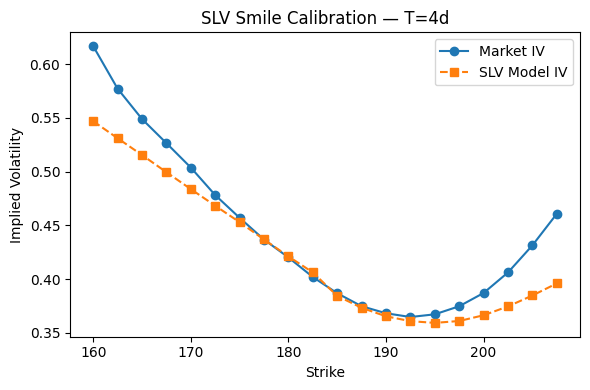


  T = 0.0877  (32d)   max |Δ IV| = 0.2634   !
    K=  140.0  mkt=0.5666  SLV=0.3032  err=0.2634
    K=  145.0  mkt=0.5387  SLV=0.3534  err=0.1853
    K=  150.0  mkt=0.5142  SLV=0.3965  err=0.1177
    K=  155.0  mkt=0.4920  SLV=0.4172  err=0.0747
    K=  160.0  mkt=0.4720  SLV=0.4223  err=0.0497
    K=  165.0  mkt=0.4500  SLV=0.4191  err=0.0309
    K=  170.0  mkt=0.4309  SLV=0.4118  err=0.0192
    K=  175.0  mkt=0.4125  SLV=0.4028  err=0.0097
    K=  180.0  mkt=0.3965  SLV=0.3934  err=0.0031
    K=  185.0  mkt=0.3813  SLV=0.3564  err=0.0249
    K=  190.0  mkt=0.3678  SLV=0.3489  err=0.0190
    K=  195.0  mkt=0.3570  SLV=0.3433  err=0.0138
    K=  200.0  mkt=0.3491  SLV=0.3401  err=0.0090
    K=  205.0  mkt=0.3435  SLV=0.3397  err=0.0038
    K=  210.0  mkt=0.3421  SLV=0.3409  err=0.0011
    K=  215.0  mkt=0.3434  SLV=0.3439  err=0.0004
    K=  220.0  mkt=0.3477  SLV=0.3478  err=0.0001
    K=  225.0  mkt=0.3542  SLV=0.3525  err=0.0017
    K=  230.0  mkt=0.3635  SLV=0.3583  err=0.0052
   

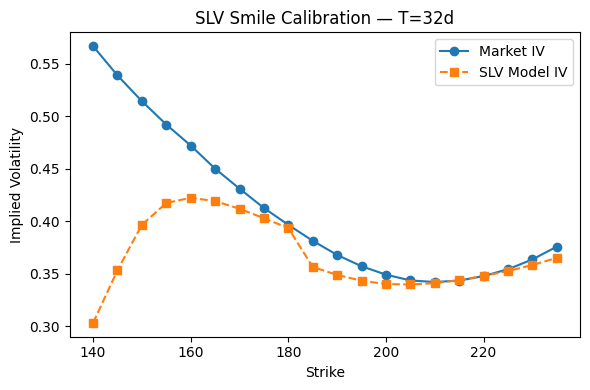


  T = 0.1644  (60d)   max |Δ IV| = 0.0496   !
    K=  140.0  mkt=0.5188  SLV=0.4692  err=0.0496
    K=  145.0  mkt=0.5010  SLV=0.4625  err=0.0384
    K=  150.0  mkt=0.4845  SLV=0.4553  err=0.0291
    K=  155.0  mkt=0.4696  SLV=0.4476  err=0.0220
    K=  160.0  mkt=0.4541  SLV=0.4393  err=0.0148
    K=  165.0  mkt=0.4407  SLV=0.4313  err=0.0094
    K=  170.0  mkt=0.4270  SLV=0.4237  err=0.0033
    K=  175.0  mkt=0.4158  SLV=0.4164  err=0.0006
    K=  180.0  mkt=0.4040  SLV=0.4098  err=0.0058
    K=  185.0  mkt=0.3941  SLV=0.3662  err=0.0279
    K=  190.0  mkt=0.3873  SLV=0.3609  err=0.0265
    K=  195.0  mkt=0.3781  SLV=0.3562  err=0.0219
    K=  200.0  mkt=0.3715  SLV=0.3523  err=0.0192
    K=  205.0  mkt=0.3633  SLV=0.3494  err=0.0139
    K=  210.0  mkt=0.3606  SLV=0.3475  err=0.0131
    K=  215.0  mkt=0.3582  SLV=0.3465  err=0.0117
    K=  220.0  mkt=0.3566  SLV=0.3462  err=0.0103
    K=  225.0  mkt=0.3562  SLV=0.3467  err=0.0095
    K=  230.0  mkt=0.3567  SLV=0.3478  err=0.0089
   

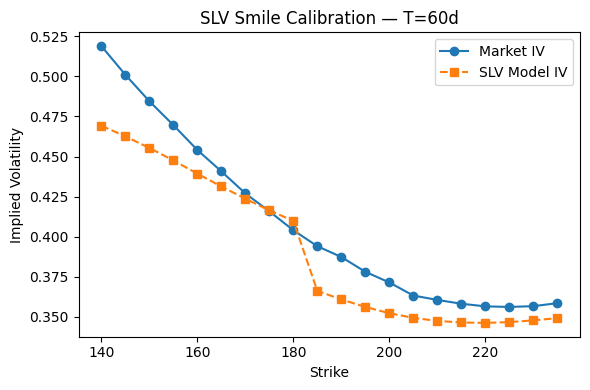


  T = 0.2575  (94d)   max |Δ IV| = 0.0529   !
    K=  174.0  mkt=0.4428  SLV=0.4305  err=0.0122
    K=  175.0  mkt=0.4397  SLV=0.4296  err=0.0101
    K=  176.0  mkt=0.4362  SLV=0.4287  err=0.0075
    K=  177.0  mkt=0.4346  SLV=0.4278  err=0.0068
    K=  178.0  mkt=0.4330  SLV=0.4270  err=0.0060
    K=  179.0  mkt=0.4311  SLV=0.4262  err=0.0049
    K=  180.0  mkt=0.4307  SLV=0.4254  err=0.0053
    K=  181.0  mkt=0.4322  SLV=0.4247  err=0.0075
    K=  182.0  mkt=0.4287  SLV=0.4240  err=0.0047
    K=  183.0  mkt=0.4301  SLV=0.4233  err=0.0068
    K=  184.0  mkt=0.4277  SLV=0.3748  err=0.0528
    K=  185.0  mkt=0.4271  SLV=0.3741  err=0.0529
    K=  186.0  mkt=0.4232  SLV=0.3734  err=0.0497
    K=  187.0  mkt=0.4246  SLV=0.3727  err=0.0518
    K=  188.0  mkt=0.4236  SLV=0.3720  err=0.0516
    K=  189.0  mkt=0.4217  SLV=0.3713  err=0.0504
    K=  190.0  mkt=0.4200  SLV=0.3706  err=0.0494
    K=  191.0  mkt=0.4181  SLV=0.3699  err=0.0481
    K=  192.0  mkt=0.4163  SLV=0.3693  err=0.0470
   

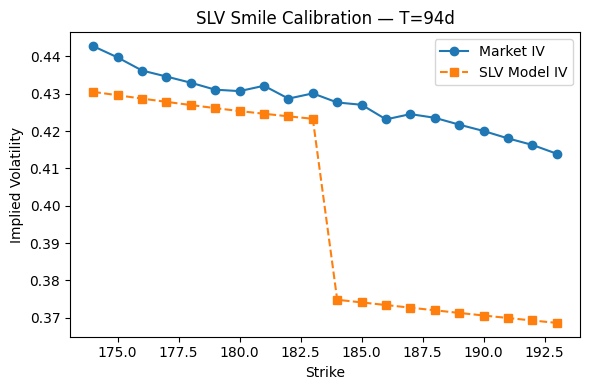

In [10]:
sigma0_slv   = 0.4370
Y0_slv       = 0.0934
rho_slv      = 0.1660
gamma_slv    = 1.0358
kappa_mr_slv = 5.30
kappa_bw_slv = 1.0
N_cal_slv    = 50_000
print("="*60)
print("SLV smile calibration check")
print("="*60)

for exp in expiries:
    T_cal       = exp['T']
    r_cal       = exp['R']
    n_steps_cal = max(20, int(100 * T_cal))

    # run particle method with the Heston-based local vol
    _, logS_cal, _ = particle_method(
        S0_nvda, sigma0_slv, Y0_slv, rho_slv, gamma_slv, kappa_mr_slv,
        T_cal, n_steps_cal, N_cal_slv, vol_fn_heston, kappa_bw_slv)
    S_T = np.exp(logS_cal)

    K_list = np.array(exp['strikes'])
    iv_mkt = np.array(exp['ivs'])

    # MC prices → IVs
    call_mc = np.array([np.maximum(S_T - K_, 0).mean() for K_ in K_list])
    put_mc  = np.array([np.maximum(K_ - S_T, 0).mean() for K_ in K_list])
    F_mc    = S_T.mean()

    iv_model = np.array([
        blackscholes_impv_scalar(
            K_, T_cal, S0_nvda, float(p),
            r=r_cal, q=0.0,
            callput=('put' if K_ < F_mc else 'call'))
        for K_, p in zip(K_list,
                         np.where(K_list < F_mc, put_mc, call_mc))
    ])

    max_err = np.nanmax(np.abs(iv_model - iv_mkt))
    print(f"\n  T = {T_cal:.4f}  ({int(T_cal*365)}d)   max |Δ IV| = {max_err:.4f}"
          f"   {'✓' if max_err < 0.01 else '!'}")
    for K_, ivm, ivmod in zip(K_list, iv_mkt, iv_model):
        print(f"    K={K_:>7.1f}  mkt={ivm:.4f}  SLV={ivmod:.4f}"
              f"  err={abs(ivmod-ivm):.4f}")

    # plot
    plt.figure(figsize=(6, 4))
    plt.plot(K_list, iv_mkt,   'o-',  label='Market IV')
    plt.plot(K_list, iv_model, 's--', label='SLV Model IV')
    plt.xlabel('Strike');  plt.ylabel('Implied Volatility')
    plt.title(f'SLV Smile Calibration — T={int(T_cal*365)}d')
    plt.legend();  plt.tight_layout();  plt.show()

In [11]:
lev_store_diag, _, _ = particle_method(
    S0_nvda, sigma0_slv, Y0_slv, rho_slv, gamma_slv, kappa_mr_slv,
    0.1644, max(20, int(100 * 0.1644)), N_cal_slv, vol_fn_heston, kappa_bw_slv)

print("Leverage diagnostics for T=60d:")
for k, (sg, lg) in enumerate(lev_store_diag):
    if lg.min() < 0.05 or lg.max() > 10:
        print(f"  step {k}: lev min={lg.min():.4f} max={lg.max():.4f} S=[{sg.min():.1f},{sg.max():.1f}]")

print(f"\nOverall lev: min={np.concatenate([lg for _,lg in lev_store_diag]).min():.4f} "
      f"max={np.concatenate([lg for _,lg in lev_store_diag]).max():.4f} "
      f"mean={np.concatenate([lg for _,lg in lev_store_diag]).mean():.4f}")

Leverage diagnostics for T=60d:
  step 2: lev min=0.0163 max=1.3221 S=[132.4,232.7]
  step 3: lev min=0.0202 max=1.4306 S=[124.1,250.6]
  step 4: lev min=0.0191 max=1.4170 S=[123.7,259.3]
  step 5: lev min=0.0152 max=1.3875 S=[121.2,264.7]
  step 6: lev min=0.0136 max=1.3831 S=[120.8,273.6]
  step 7: lev min=0.0147 max=1.7583 S=[117.0,292.8]
  step 8: lev min=0.0171 max=1.7638 S=[116.0,311.2]
  step 9: lev min=0.0175 max=1.6921 S=[116.4,300.0]
  step 10: lev min=0.0160 max=1.6255 S=[115.9,305.2]

Overall lev: min=0.0136 max=2.0994 mean=0.8218


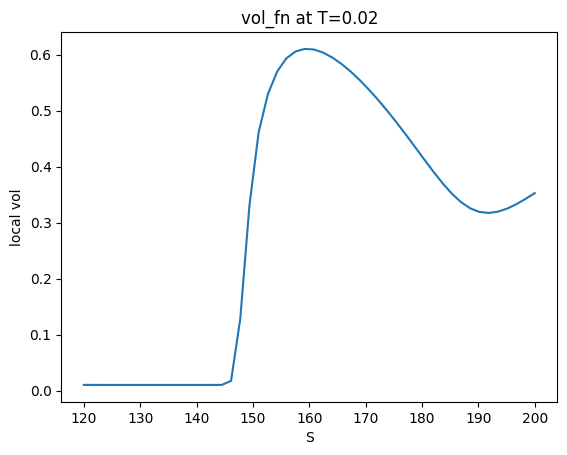

In [12]:
S_test = np.linspace(120, 200, 50)
t_test = 0.02
lv_test = vol_fn_heston(S_test, t_test)
plt.plot(S_test, lv_test)
plt.xlabel('S')
plt.ylabel('local vol')
plt.title('vol_fn at T=0.02')
plt.show()

In [13]:
S_test = np.linspace(120, 200, 50)
for t_test in [0.02, 0.05, 0.09, 0.16]:
    lv_test = vol_fn_heston(S_test, t_test)
    print(f"T={t_test:.2f}: min={lv_test.min():.4f} max={lv_test.max():.4f} "
          f"n_below_0.1={np.sum(lv_test < 0.1)}")

T=0.02: min=0.0100 max=0.6105 n_below_0.1=17
T=0.05: min=0.0100 max=0.4782 n_below_0.1=16
T=0.09: min=0.3277 max=0.5675 n_below_0.1=0
T=0.16: min=0.3540 max=0.5576 n_below_0.1=0


In [14]:
T_test = 0.02
K_test = np.linspace(120, 160, 20)
r_test = np.interp(T_test, [e['T'] for e in expiries], [e['R'] for e in expiries])
q_test = 0.0
v0, kappa_h, theta_h, xi_h, rho_h = heston_params
prices = heston_call_grid(S0_nvda, K_test, T_test, r_test, q_test,
                          v0, kappa_h, theta_h, xi_h, rho_h)
for K, p in zip(K_test, prices):
    print(f"K={K:.1f}  call={p:.6f}")

K=120.0  call=63.315148
K=122.1  call=61.211636
K=124.2  call=59.108168
K=126.3  call=57.004768
K=128.4  call=54.901467
K=130.5  call=52.798313
K=132.6  call=50.695372
K=134.7  call=48.592738
K=136.8  call=46.490546
K=138.9  call=44.388979
K=141.1  call=42.288294
K=143.2  call=40.188842
K=145.3  call=38.091102
K=147.4  call=35.995718
K=149.5  call=33.903554
K=151.6  call=31.815755
K=153.7  call=29.733833
K=155.8  call=27.659760
K=157.9  call=25.596092
K=160.0  call=23.546114
